# LeetCode #45: Jump Game II

https://leetcode.com/problems/jump-game-ii/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **BFS / DP** | $O(n^2)$ | $O(n)$ |
| **Greedy curEnd/farthest** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### BFS / DP
Treat each index as a BFS level; explore all reachable next positions level by level. Or maintain a DP array `dp[i]` = min jumps to reach i. Both are $O(n^2)$ in the worst case.

### Optimal: Greedy curEnd/farthest ★
Track three variables:
- `curEnd`: the furthest index reachable in the **current** jump
- `farthest`: the furthest index reachable from **any** position in the current jump
- `jumps`: count of jumps taken

Scan i from 0 to n-2. At each i, update `farthest = max(farthest, i + nums[i])`. When `i == curEnd`, we **must** jump (we've explored all positions in this jump): `jumps++`, `curEnd = farthest`.

**Why greedy is optimal:** At any jump boundary, choosing the position that extends farthest is always at least as good as any other choice — because the next jump starts from the same set.

**Constraints:**
* $1 \leq$ nums.length $\leq 10^4$
* $0 \leq$ nums[i] $\leq 1000$
* The input is guaranteed to reach the last index

## Solutions

### C#

In [ ]:
public class Solution {
    public int Jump(int[] nums) {
        int jumps = 0, curEnd = 0, farthest = 0;
        for (int i = 0; i < nums.Length - 1; i++) {
            farthest = Math.Max(farthest, i + nums[i]);
            if (i == curEnd) {
                jumps++;
                curEnd = farthest;
            }
        }
        return jumps;
    }
}

### Python

In [ ]:
from typing import List

class Solution:
    def jump(self, nums: List[int]) -> int:
        jumps = cur_end = farthest = 0
        for i in range(len(nums) - 1):
            farthest = max(farthest, i + nums[i])
            if i == cur_end:
                jumps += 1
                cur_end = farthest
        return jumps

### Go

In [ ]:
package main

func jump(nums []int) int {
	jumps, curEnd, farthest := 0, 0, 0
	for i := 0; i < len(nums)-1; i++ {
		if i+nums[i] > farthest {
			farthest = i + nums[i]
		}
		if i == curEnd {
			jumps++
			curEnd = farthest
		}
	}
	return jumps
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn jump(nums: Vec<i32>) -> i32 {
        let (mut jumps, mut cur_end, mut farthest) = (0i32, 0usize, 0usize);
        let n = nums.len();
        for i in 0..n - 1 {
            farthest = farthest.max(i + nums[i] as usize);
            if i == cur_end {
                jumps += 1;
                cur_end = farthest;
            }
        }
        jumps
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `nums = [2, 3, 1, 1, 4]`

Walk through: Start at index 0 (value 2). At each boundary (`i == curEnd`), jump and set `curEnd = farthest`. At i=0, farthest=2, jump #1. At i=2, farthest=4, jump #2. Done.

**Why tricky:** Straightforward greedy — interviewers use it to confirm you understand the curEnd/farthest mechanism before harder cases. $O(n)$ time, $O(1)$ space.

### 2. Slightly Complex — Multiple Viable Paths
**Input:** `nums = [1, 2, 1, 1, 2, 1, 1]`

Walk through: Multiple paths exist (e.g., 0→1→3→4→6 = 4 jumps vs 0→1→2→3→4→5→6 = 6 jumps). Greedy picks the farthest-reaching option at each boundary, yielding 4 jumps without evaluating all paths.

**Why tricky:** A BFS/DP approach explores every path — $O(n^2)$ in the worst case. Greedy avoids this by proving "farthest reach at each level is always optimal." Interviewers look for this justification.

### 3. Edge Case: Time Factor — All Ones ($n = 10^4$)
**Input:** `nums = [1, 1, 1, ..., 1]` (10,000 elements)

Walk through: Every position triggers a jump boundary (`i == curEnd` at every step). Total jumps = 9,999. The greedy scan is $O(n) = 10^4$ operations. A BFS/DP solution degrades to $O(n^2) \approx 10^8$, risking TLE.

**Why tricky:** Worst case for time — forces a full scan with no shortcuts. Separates $O(n)$ greedy from $O(n^2)$ DP. Interviewers verify your solution doesn't degrade.

### 4. Edge Case: Space Factor — Large Jump Values
**Input:** `nums = [1000, 1000, 1000, ..., 1000]` (10,000 elements, all 1000)

Walk through: First jump reaches index 1000 in one step. Each subsequent jump spans 1000 indices. Total jumps $\approx \lceil 9999/1000 \rceil = 10$. Greedy uses $O(1)$ space (3 integers). A DP solution allocates an $O(n)$ array.

**Why tricky:** Large values mean few jumps but the array is still large. DP wastes space tracking every index. Interviewers want to hear that greedy's $O(1)$ space advantage matters when $n$ is large.

### 5. Almost-Impossible but Plausible — Single Element [0]
**Input:** `nums = [0]`

Walk through: Loop runs over `range(0, n-1) = range(0, 0)` — body never executes. Return `jumps = 0`. The value at index 0 is 0, but we're already at the last index.

**Why tricky:** Off-by-one errors are the #1 bug. The loop must iterate `[0, n-2]`, NOT `[0, n-1]`. Iterating to `n-1` would trigger a jump at the last index (wrong). A value of 0 at the only position looks like "can't jump" but the answer is 0 jumps needed.

---

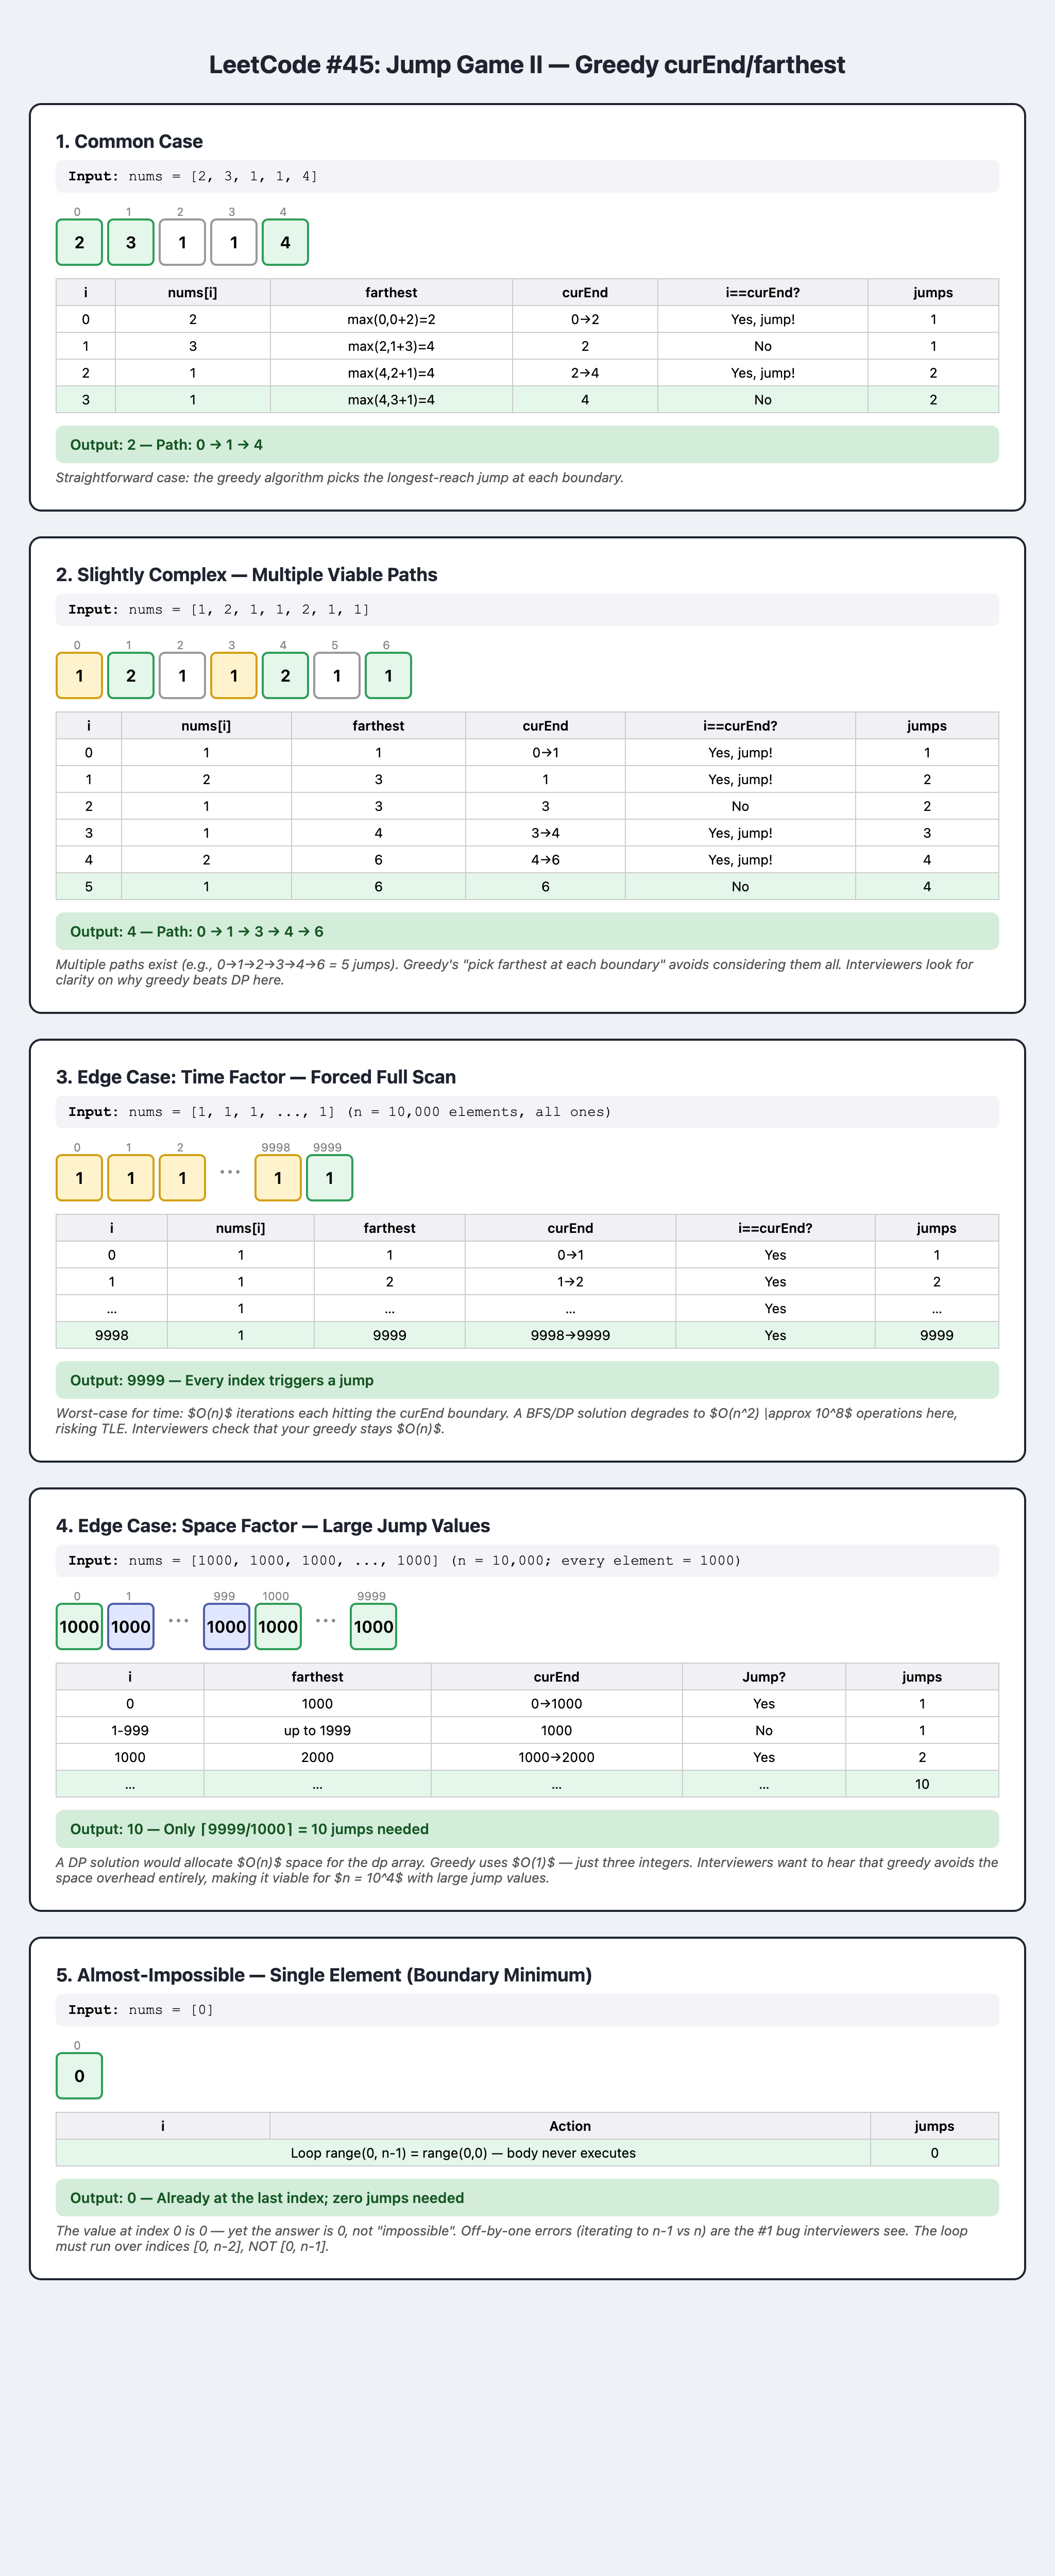